## Apresentação ✒️

Notebook destinado à implementação dos modelos de regressão linear e de SVM Regressor. O primeiro pode ser compreendido como uma generalização da função de 1° grau que permite compreender o valor contínuo associado a um determinado conjunto de dados com base no seu ajuste anterior, realizado na etapa de treinamento, por meio da técnica conhecida como mínimos quadrados. Ao mesmo tempo, trabalha com a suposição de que as features apresentam uma relação linear em relação à target e que apresentam erros idenpendentes e homocedásticos. 

O segundo se trata de uma adaptação do modelo de Suport Vector Machine para o escopo de regressão, o qual é constituiído por meio da união do hiperplano com os vetores de suporte que formam a margem superior e inferior. 

Por fim, importante salientar que no contexto de regressão as métricas utilizadas para mensurar a qualidade de ajuste do modelo são :

- RSE

- MSE

- RMSE

- MAE

- R² e R² ajustado 

Como o foco desse notebook não se circunscreve no estudo acerca de cada métrica, estarei deixando um link para o artigo que se debruça sobre elas, o qual compreende também as métricas que são utilizadas em contexto de classificação : [Métricas de avaliação para Machine Learning](https://medium.com/@brunoloducca15/métricas-de-avaliação-para-machine-learning-249f16d104da)


### Library 📚

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pandas import DataFrame

from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

### Carregando o dataset 💾

In [2]:
file_path = "house_prices.csv"

df = pd.read_csv(file_path)

df.head()

,Id,area_primeiro_andar,existe_segundo_andar,area_segundo_andar,quantidade_banheiros,capacidade_carros_garagem,qualidade_da_cozinha_Excelente,preco_de_venda
0,1,79.5224,1,79.3366,2,548,0,1027905.0
1,2,117.2398,0,0.0000,2,460,0,894795.0
2,3,85.4680,1,80.4514,2,608,0,1101855.0
3,4,89.2769,1,70.2324,1,642,0,690200.0
4,5,106.3705,1,97.8237,2,836,0,1232500.0


In [3]:
df = df.drop("Id", axis=1)

### Analisando a integridade do dataset

In [4]:
df.isnull().sum()

area_primeiro_andar               0
existe_segundo_andar              0
area_segundo_andar                0
quantidade_banheiros              0
capacidade_carros_garagem         0
qualidade_da_cozinha_Excelente    0
preco_de_venda                    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(1)

In [6]:
df = df.drop_duplicates()

### Exploração dos dados


In [7]:
# Verificando a correlação entre freatures

def pearson_matrix(
        dataset: DataFrame, 
        color: str, 
        height: int, 
        width: int
    ):
    corr_matrix = dataset.corr()

    plt.figure(figsize=(height, width))
    sns.heatmap(corr_matrix, annot=True, cmap=color, fmt=".2f")

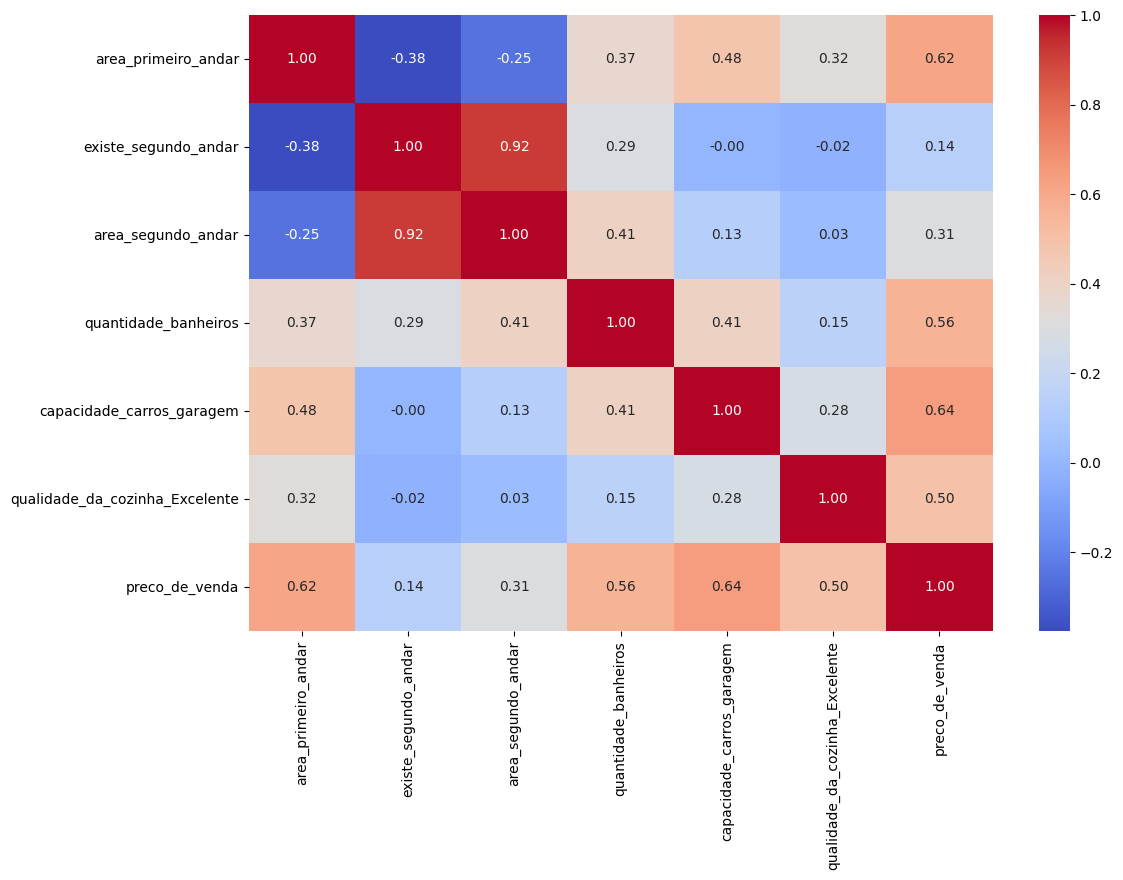

In [9]:
pearson_matrix(
    dataset = df, 
    color   = "coolwarm", 
    height  = 12, 
    width   = 8
)

Analisando a matriz de correlação, pode-se compreender que as features apresentam relação linear com a target, ao mesmo tempo em que se nota a presença de colinearidade entre `área do segundo andar` e `existe segundo andar`. Por questão de melhor a precisão do modelo em relação ao entendimento do padrão subjacente aos dados, recomenda-se a retirada da colinearidade no dataset, a qual pode ser realizada por meio da exclusão da feature ou por sua aglutinação - por assim dizer - com a outra feature altamente correlacioanada, por meio do PCA. No presente notebook, irei optar pela remoção de uma das features correlacionadas. 



In [10]:
df = df.drop("existe_segundo_andar", axis=1)

In [11]:
df.head(1)

,area_primeiro_andar,area_segundo_andar,quantidade_banheiros,capacidade_carros_garagem,qualidade_da_cozinha_Excelente,preco_de_venda
0,79.5224,79.3366,2,548,0,1027905.0


In [12]:
# Verificando a presença de outliers por meio do gráfico de boxplot 

# Verificando a presença de outliers nos dados por meio do recurso
# conhecido como boxplot, um gráfico que compreende a distribuição 
# dos dados, segundo um percentual conhecido como quartis. 

def boxplot(
          dataset: DataFrame, 
          style : str, 
          height : int, 
          width : int
      ):
      
      """ 
      Generates a series of boxplots for each feature in the provided dataset.

      This function uses Seaborn and Matplotlib to create boxplots for all columns in the dataset. 
      The visual style of the plots is set using the provided style parameter. The plots are arranged 
      in a grid layout with 2 rows and 3 columns, and the figure size is determined by the height and 
      width parameters.

      Args:
        dataset (DataFrame): The dataset containing the features to be visualized.
        style (str): The Seaborn style theme to be applied to the plots (e.g., "darkgrid", "whitegrid").
        height (int): The height of the overall figure.
        width (int): The width of the overall figure.

      Returns:
        None: This function displays the boxplots directly using Matplotlib's `plt.show()`.
      """

      sns.set_theme(style=style)
      
      feature = dataset.columns
      plt.figure(figsize=(height, width))

      for i, feature in enumerate(feature, 1):
          plt.subplot(2, 3, i)
          sns.boxplot(data=df[feature])
          plt.title(f"Boxplot de {feature}")
      
      plt.tight_layout()
      plt.show()

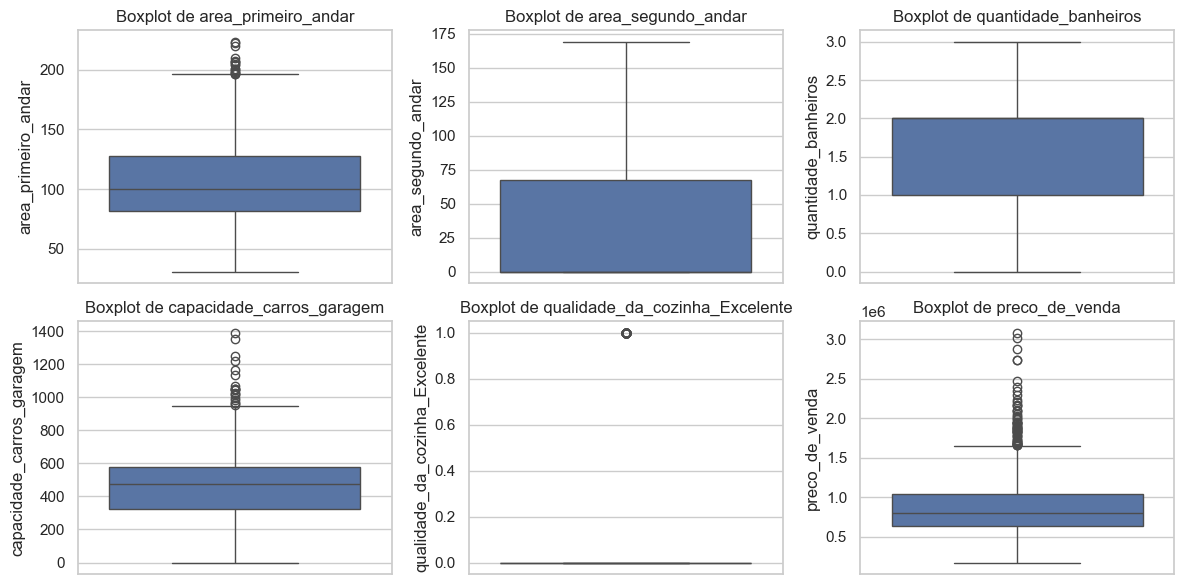

In [13]:
boxplot(
    dataset = df,
    style   = "whitegrid", 
    height  = 12, 
    width   = 6
)


Observando os gráficos gerados, nota-se a presença de outliers em três features, de modo que seria recomendado realizar um pré-tratamento antes de passar ao modelo, de tal modo a produzir melhor qualidade de ajuste. Contudo, como o objetivo do presente notebook se constitui apenas em realizar a implementação - afinal é um mise en place - dos modelos, o único pré-tratamento realizado será colocar as features numa mesma escala, assim como a variável target por meio de uma normalização. 

In [14]:
# Verificando a distribuição dos dados

def data_distribuition(
        dataset: DataFrame, 
        style : str, 
        height: int, 
        width: int, 
        bins: int
        ):
    """ 
    Visualizes the distribution of each feature in the dataset using histograms.

    Parameters:
    ----------
    dataset : DataFrame
        The dataset to be visualized, where each column represents a feature.
    
    style : str
        Seaborn theme for plot styling (e.g., 'darkgrid', 'whitegrid').
    
    height : int
        The height of the figure in inches.
    
    width : int
        The width of the figure in inches.
    
    bins : int
        Number of bins for the histograms.
    """
    feature = dataset.columns
    sns.set_theme(style=style)

    # Determinar o número de linhas no grid :
    
    # Fixo para 3 colunas
    n_cols = 3 

    # Calcular o número de linhas necessárias
    n_rows = (len(feature) + n_cols - 1) // n_cols  

    plt.figure(figsize=(height, width))

    for i, feature in enumerate(feature, 1):

        data = dataset[feature]

        plt.subplot(n_rows, n_cols, i)
        sns.histplot(data, kde=True, bins=bins)
        plt.title(f"Histograma de {feature}")


    plt.tight_layout()
    plt.show()

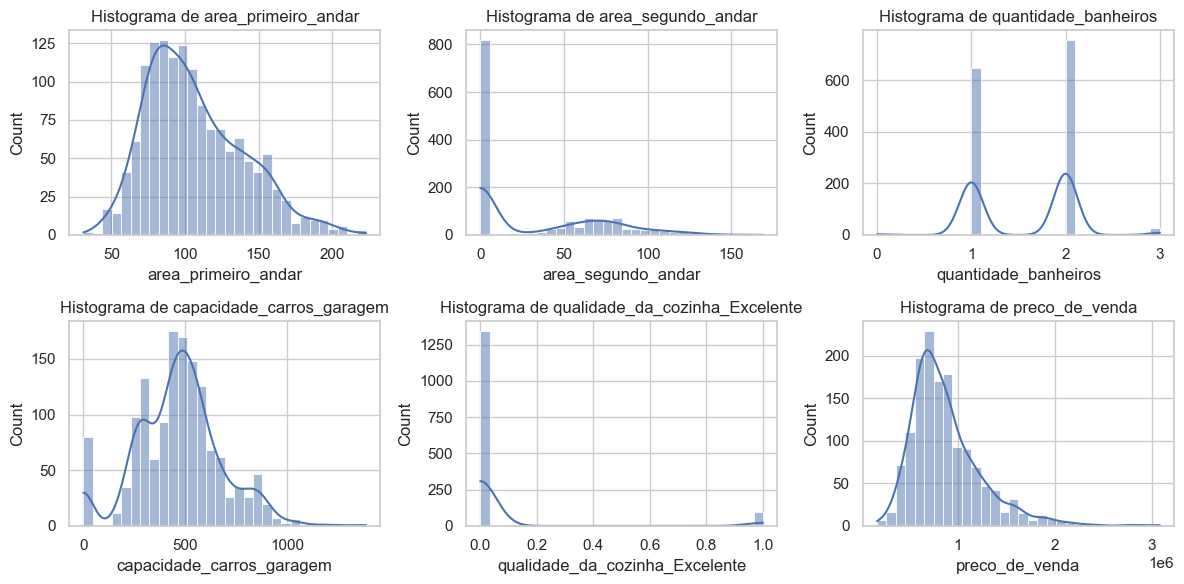

In [15]:
data_distribuition(
    dataset = df,
    style   = "whitegrid", 
    height  = 12, 
    width   = 6, 
    bins    = 30
)